In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/raw/household_power_consumption.txt",
    sep=";",
    na_values="?",
    low_memory=False
)

df.head()

ParserError: Error tokenizing data. C error: out of memory

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [ ]:
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
df.drop(['Date', 'Time'], axis=1, inplace=True)

In [ ]:
df = df.apply(pd.to_numeric)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


In [ ]:
df.isnull().sum()

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [ ]:
df = df.dropna()

In [ ]:
energy = df['Global_active_power']
energy.head()

datetime
2006-12-16 17:24:00    4.216
2006-12-16 17:25:00    5.360
2006-12-16 17:26:00    5.374
2006-12-16 17:27:00    5.388
2006-12-16 17:28:00    3.666
Name: Global_active_power, dtype: float64

In [ ]:
energy_hourly = energy.resample('H').mean()
energy_hourly.head()

C:\Users\AARON\AppData\Local\Temp\ipykernel_68820\1153685551.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  energy_hourly = energy.resample('H').mean()


datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float64

### Multi-Year Trend

The dataset spans multiple years and shows consistent fluctuations, indicating potential seasonality.

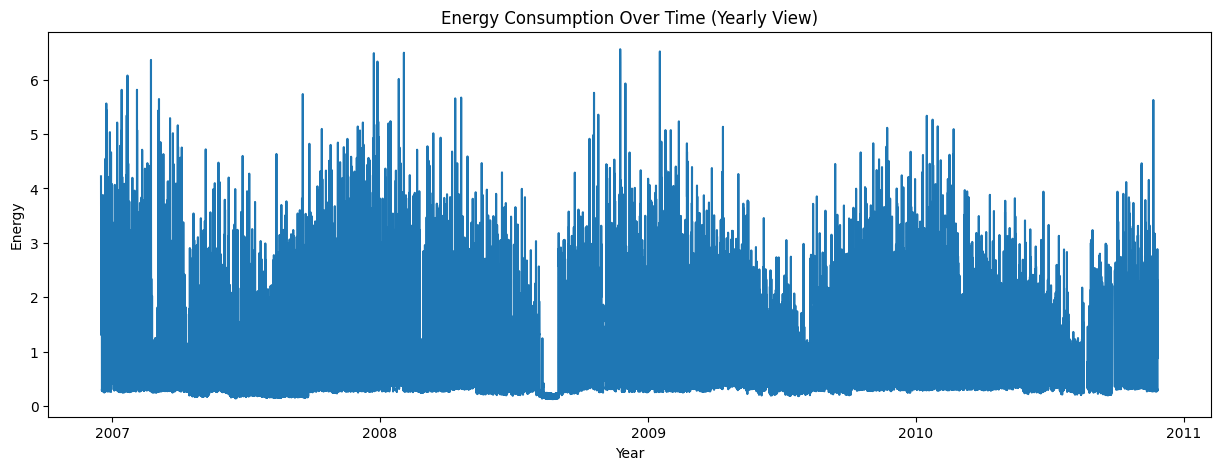

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(15,5))
ax.plot(energy_hourly)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title('Energy Consumption Over Time (Yearly View)')
plt.xlabel('Year')
plt.ylabel('Energy')
plt.show()

### Monthly Trend

Monthly aggregation smooths short-term fluctuations and highlights the underlying trend.

C:\Users\AARON\AppData\Local\Temp\ipykernel_68820\3733982130.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = energy_hourly.resample('M').mean()


<Axes: xlabel='datetime'>

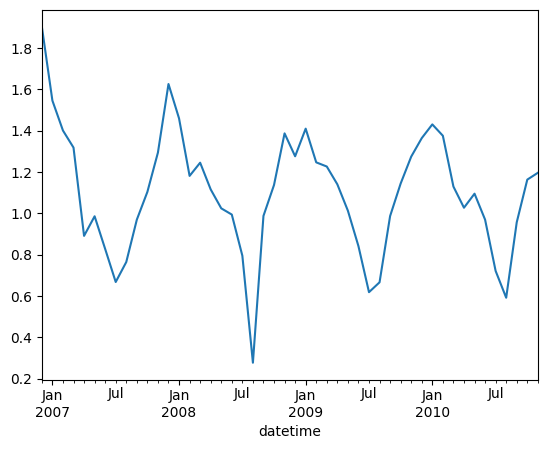

In [ ]:
monthly = energy_hourly.resample('M').mean()
monthly.plot()

### Short-Term Pattern Analysis (1-Week Zoom)

This plot shows energy consumption over a one-week period to highlight short-term fluctuations and repeating patterns. It helps visualize intra-day variations and confirms the presence of daily seasonality.

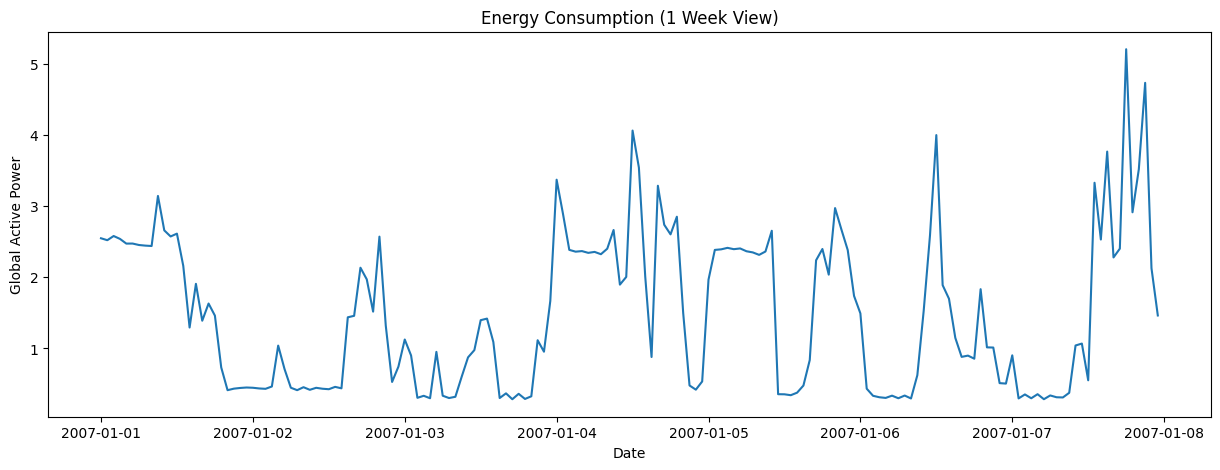

In [ ]:
week_data = energy_hourly['2007-01-01':'2007-01-07']

plt.figure(figsize=(15,5))
plt.plot(week_data)
plt.title('Energy Consumption (1 Week View)')
plt.xlabel('Date')
plt.ylabel('Global Active Power')
plt.show()

### Hourly Trend

Energy usage peaks during evening hours and is lowest during night time.

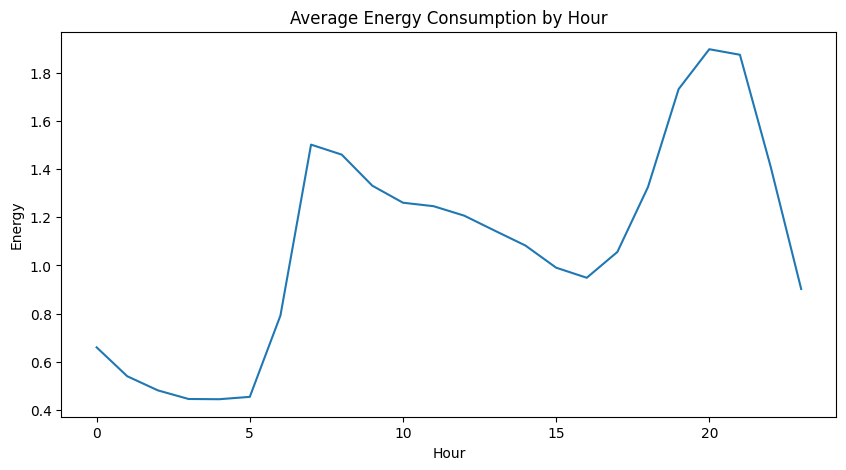

In [ ]:
energy_hourly = energy_hourly.to_frame()

energy_hourly['hour'] = energy_hourly.index.hour

hourly_avg = energy_hourly.groupby('hour')['Global_active_power'].mean()

hourly_avg = hourly_avg.reindex(range(24))

plt.figure(figsize=(10,5))
hourly_avg.plot()
plt.title('Average Energy Consumption by Hour')
plt.xlabel('Hour')
plt.ylabel('Energy')
plt.show()

### Weekly Seasonality Analysis

This plot represents the average energy consumption for each day of the week, aggregated across the entire dataset. It helps identify whether there are consistent behavioral differences between weekdays and weekends.

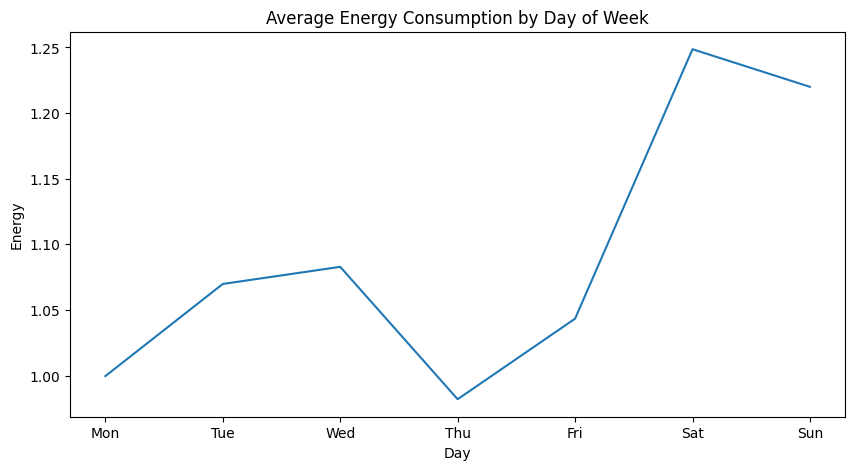

In [ ]:
energy_hourly['day'] = energy_hourly.index.dayofweek

weekly_avg = energy_hourly.groupby('day')['Global_active_power'].mean()

weekly_avg.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10,5))
weekly_avg.plot()
plt.title('Average Energy Consumption by Day of Week')
plt.xlabel('Day')
plt.ylabel('Energy')
plt.show()

### Rolling Mean

Rolling mean highlights the underlying trend by smoothing short-term fluctuations.

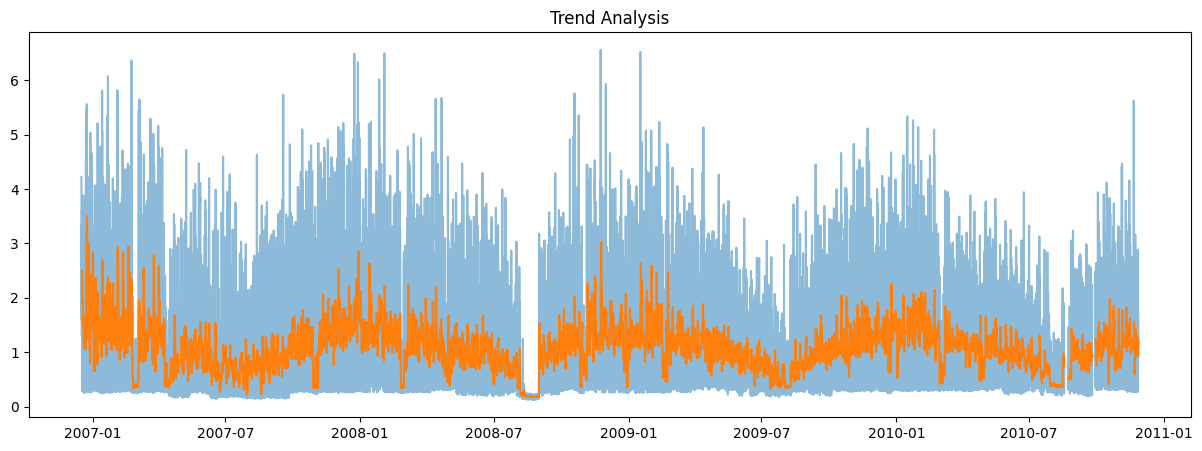

In [ ]:
energy_hourly['rolling_mean'] = energy_hourly['Global_active_power'].rolling(24).mean()

plt.figure(figsize=(15,5))
plt.plot(energy_hourly['Global_active_power'], alpha=0.5)
plt.plot(energy_hourly['rolling_mean'])
plt.title('Trend Analysis')
plt.show()

**Key Observations:**
- Strong daily seasonality observed (hourly peaks)
- Higher consumption during evening hours
- Moderate variation across days of the week
- Data contains missing values (handled temporarily)
- Overall trend appears stable/slightly varying   